In [4]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
import numpy.random as rng

fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

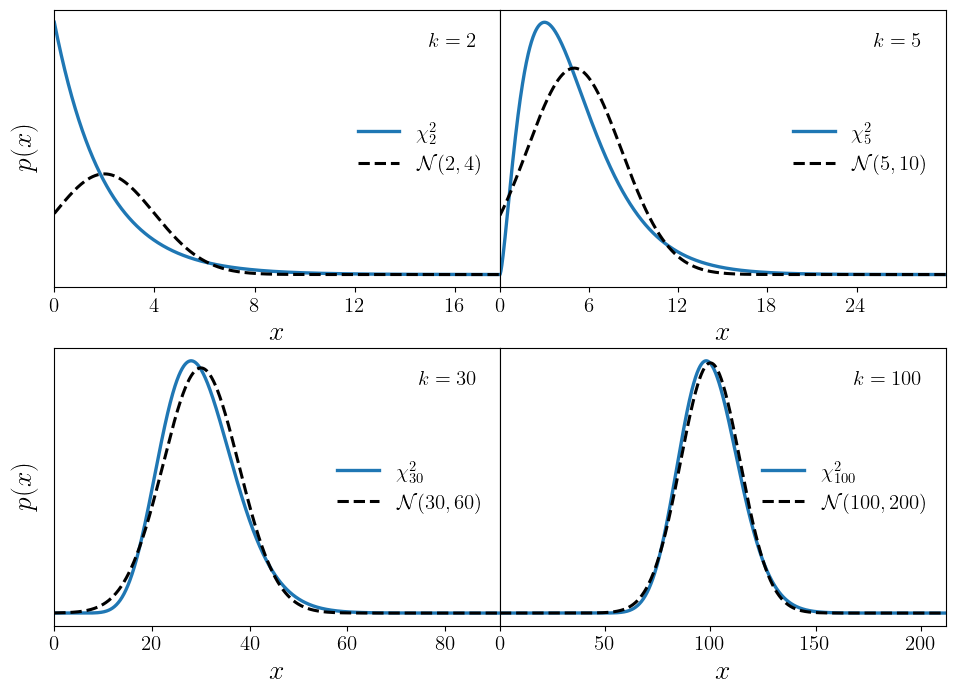

In [21]:
from math import gamma
from matplotlib.ticker import MaxNLocator


def chi2_pdf(x, k):
    # Chi-square PDF with k degrees of freedom.
    coef = 1.0 / (2.0 ** (k / 2.0) * gamma(k / 2.0))
    return coef * x ** (k / 2.0 - 1.0) * np.exp(-x / 2.0)


def gaussian_approx_pdf(x, k):
    # CLT approximation: chi^2_k ~ N(k, 2k) for large k.
    mu = k
    sigma = np.sqrt(2.0 * k)
    return (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-((x - mu) ** 2) / (2.0 * sigma**2))


ks = [2, 5, 30, 100]
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0), sharex=False, sharey=False)

for ax, k in zip(axes.flat, ks):
    xmax = max(12.0, k + 7.9 * np.sqrt(2.0 * k))
    x = np.linspace(1e-6, xmax, 1400)

    ax.plot(x, chi2_pdf(x, k), color='tab:blue', lw=2.4, label=rf"$\chi^2_{{{k}}}$")
    ax.plot(x, gaussian_approx_pdf(x, k), 'k--', lw=2.2, label=rf"$\mathcal{{N}}({k}, {2 * k})$")

    ax.text(
        0.95, 0.92, rf'$k={k}$',
        transform=ax.transAxes, ha='right', va='top', fontsize=fontsi,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.7', alpha=0.),
    )
    ax.set_xlabel(r'$x$', fontsize=fontsi2)
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.tick_params(labelsize=fontsi)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.legend(fontsize=fontsi, frameon=False, loc='center right')
    ax.set_xlim(0.0, xmax)

axes[0, 0].set_ylabel(r'$p(x)$', fontsize=fontsi2, labelpad = 12)
axes[1, 0].set_ylabel(r'$p(x)$', fontsize=fontsi2, labelpad = 12)

fig.subplots_adjust(wspace=0.0, hspace=0.22)
plt.savefig('4_plots_chi2_to_gaussian.pdf')
plt.show()

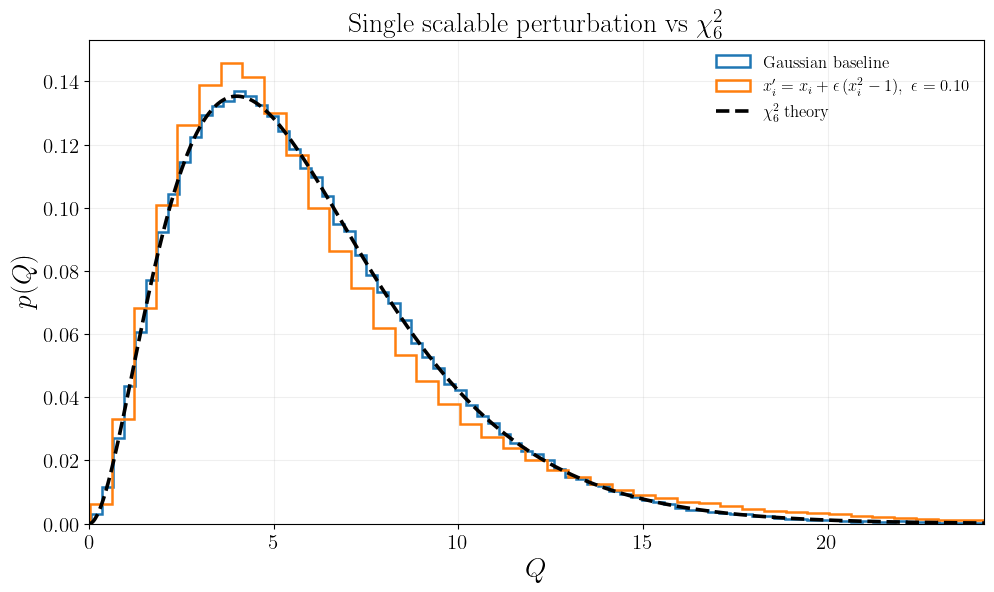

In [ ]:
d = 6
mu = np.zeros(d)

# Positive-definite covariance with off-diagonal correlations.
Sigma = 0.6 ** np.abs(np.subtract.outer(np.arange(d), np.arange(d)))
Sigma_inv = np.linalg.inv(Sigma)

n_samples = 250_000
rng_engine = np.random.default_rng(7)
X = rng_engine.multivariate_normal(mean=mu, cov=Sigma, size=n_samples)

# Quadratic form Q = (x-mu)^T Sigma^{-1} (x-mu).
Q = np.einsum("ni,ij,nj->n", X - mu, Sigma_inv, X - mu)

# Small perturbation 1 only. Increase/decrease this to scale deviation strength.
perturb_strength = 0.1
X_skew = X + perturb_strength * (X**2 - 1.0)
Q_skew = np.einsum("ni,ij,nj->n", X_skew - mu, Sigma_inv, X_skew - mu)

xmax = np.percentile(np.concatenate([Q, Q_skew]), 99.7)
x = np.linspace(0.0, xmax, 900)

fig, ax = plt.subplots(figsize=(10, 6.2))

ax.hist(
    Q,
    bins=130,
    density=True,
    histtype='step',
    linewidth=1.8,
    color='tab:blue',
    label=rf"$x\sim\mathcal{{N}}_{{{d}}}(\mu,\Sigma)$"
)
ax.hist(
    Q_skew,
    bins=130,
    density=True,
    histtype='step',
    linewidth=1.8,
    color='tab:orange',
    label=rf"$x_i' = x_i + \epsilon\,(x_i^2-1),\ \epsilon={perturb_strength:.2f}$"
)

ax.plot(x, chi2_pdf(x, d), color='k', lw=2.6, ls='--', label=rf'$\chi^2_{{{d}}}\;\mathrm{{theory}}$')

ax.set_title(rf'$\mathrm{{Single\ scalable\ perturbation\ vs}}\;\chi^2_{{{d}}}$', fontsize=fontsi2)
ax.set_xlabel(r'$Q$', fontsize=fontsi2)
ax.set_ylabel(r'$p(Q)$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.legend(fontsize=12, frameon=False, loc='upper right')
ax.set_xlim(0.0, xmax)
ax.grid(alpha=0.2)

fig.subplots_adjust(left=0.09, right=0.985, bottom=0.12, top=0.90)
plt.savefig('4_plots_mvn_to_chi2_perturbations.pdf')
plt.show()